# What can a 50-target safety panel tell you about the other 950?

An illustrative simulation study of off-target screening under shared compound-level structure.

This notebook is the executable version of `report.md`. Run the experiment cells from top to bottom to regenerate every figure and result table.

## 1. The question

Suppose there are on the order of 1000 physiological off-targets at which a small molecule could acquire a safety liability. In vitro pharmacological profiling panels screen a few tens of these; the panels described by Bowes et al. cover roughly 44 targets chosen for the severity and frequency of the adverse effects they mediate [1]. A panel that comes back clean is routinely treated as reassurance about the compound as a whole, not merely about the proteins on the plate.

That inference cannot be justified by statistical independence. If affinities at different targets were independent across compounds, learning that a compound is inactive at 50 of them would carry exactly no information about the remaining 950. The panel would license a claim about the panel and nothing else. The working assumption must instead be that affinities covary across targets: some compounds are dirty nearly everywhere and some are clean nearly everywhere.

This study asks how strong the shared structure has to be before a small panel supports a claim about the unscreened proteome, how the answer depends on panel size and tail weight, and whether the shared structure can be estimated from screening data already held.

## 2. Model

The latent affinity for compound *c* at target *t* is

$$z_{ct}=\sqrt{\rho_g}\,\phi_c+\sqrt{\rho_f}\,\psi_{c,f(t)}+\sqrt{1-\rho_g-\rho_f}\,\epsilon_{ct}.$$

There are $T=1000$ targets and $F=20$ equal families, with $M=T/F=50$ targets per family. For $t=1,\ldots,T$,

$$f(t)=1+\left\lfloor\frac{t-1}{M}\right\rfloor,\qquad F_j=\{(j-1)M+1,\ldots,jM\}.$$

The independent latent variables are $\phi_c\sim N(0,1)$, $\psi_{c,j}\sim N(0,1)$, and $U_{ct}\sim t_\nu$. The residual is standardized as $\epsilon_{ct}=\sqrt{(\nu-2)/\nu}U_{ct}$ for $\nu>2$, so it has unit variance. The coefficients satisfy $\rho_g\geq0$, $\rho_f\geq0$, and $\rho_g+\rho_f<1$.

Thus $\operatorname{Var}(z_{ct})=1$. Distinct targets in different families have correlation $\rho_g$; distinct targets in the same family have correlation $\rho_g+\rho_f$. A hit occurs when $z_{ct}>\theta$. The threshold is calibrated to give marginal hit probability $p_{hit}=0.003$ at baseline.

Given shared values $\phi_c=x$ and $\psi_{c,f(t)}=y$, the conditional hit probability is

$$q(x,y)=S_\nu\left(\sqrt{\frac{\nu}{\nu-2}}\,\frac{\theta-\sqrt{\rho_g}x-\sqrt{\rho_f}y}{\sqrt{1-\rho_g-\rho_f}}\right),$$

where $S_\nu$ is the Student-t survival function. In the exchangeable global-only case, this becomes $q(x)=S_\nu(\sqrt{\nu/(\nu-2)}(\theta-\sqrt{\rho_g}x)/\sqrt{1-\rho_g})$. The plotted pIC50 is the censored transform $\max(4.4+0.9z_{ct},4.0)$ and does not enter the risk calculations.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display

from run_all import (
    experiment_0, experiment_1, experiment_1b, experiment_2,
    experiment_3, experiment_4, experiment_5, experiment_6,
)

# The notebook uses the same deterministic seed and model implementation as run_all.py.
FIG = Path('figures')
RES = Path('results')

## 3. What we measure

The negative predictive value is the probability that a compound with a clean panel is clean everywhere else. Because it changes with the base rate of clean compounds as $\rho$ changes, the main measure is the residual risk ratio:

$$R(n)=\frac{E[\text{per-target liability rate on unscreened targets}\mid\text{panel of size }n\text{ is clean}]}{\text{unconditional per-target liability rate}}.$$

$R=1$ means the clean panel has told us nothing; $R=0.4$ means it has reduced expected liability elsewhere by 60%. Under independence, $R(n)=1$ exactly for every panel size. With no family structure, exchangeability makes the relevant quantities one-dimensional integrals over the global factor $\phi$.

## 4. Under independence a clean panel is worth nothing

With $\rho=0$, a clean 50-target panel leaves an expected $950\times0.003=2.85$ liabilities among the remaining targets. The negative predictive value is the base rate for the smaller remainder, not evidence about the compound. Whatever value a panel has as a general safety signal must therefore come from covariance.

## 5. How much covariance buys

The following cell regenerates Figure 0 and Figure 1, and writes the corresponding CSV files.

,rho,theta,base_rate_clean,p_clean_panel,npv,expected_missed,residual_risk_ratio,variance_to_mean,lift
0,0.00,3.5402,0.0496,0.8605,0.0576,2.8500,1.0000,0.9970,1.1621
1,0.05,3.4857,0.0655,0.8612,0.0760,2.8174,0.9886,1.2298,1.1611
2,0.10,3.4311,0.0824,0.8621,0.0956,2.7779,0.9747,1.5264,1.1599
3,0.15,3.3764,0.1007,0.8633,0.1166,2.7297,0.9578,1.9160,1.1584
4,0.20,3.3219,0.1205,0.8647,0.1394,2.6707,0.9371,2.4464,1.1565
5,0.25,3.2677,0.1423,0.8665,0.1642,2.5989,0.9119,3.2006,1.1540
6,0.30,3.2141,0.1664,0.8689,0.1915,2.5120,0.8814,4.3248,1.1509
7,0.35,3.1615,0.1932,0.8719,0.2216,2.4085,0.8451,6.0784,1.1470
8,0.40,3.1104,0.2233,0.8756,0.2550,2.2870,0.8024,8.9064,1.1420
9,0.45,3.0611,0.2574,0.8803,0.2924,2.1466,0.7532,13.5312,1.1359


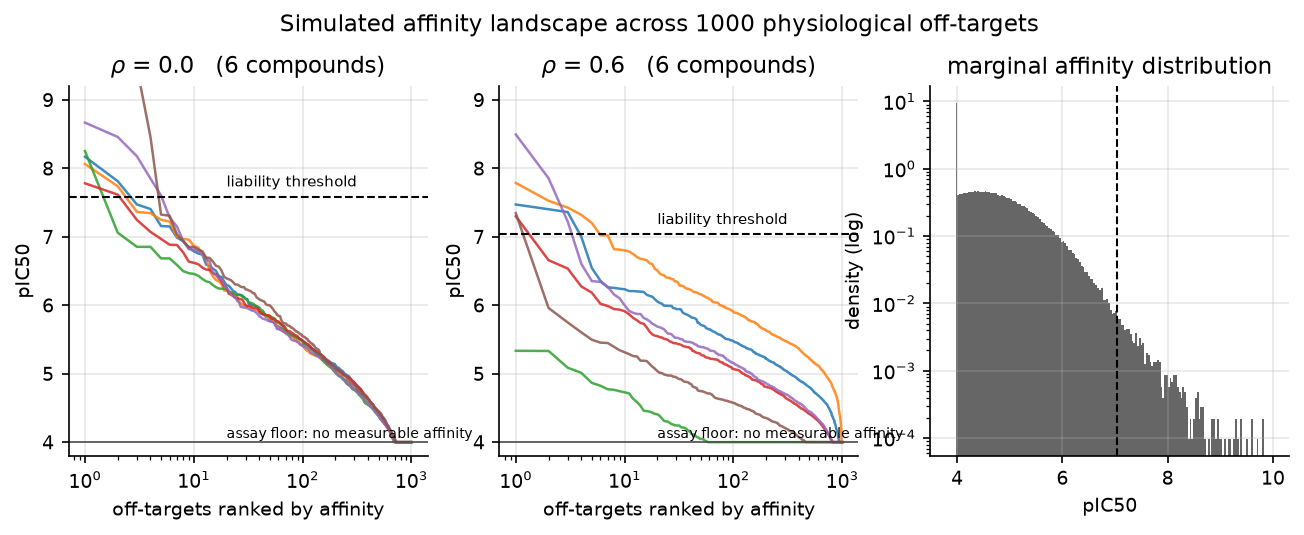

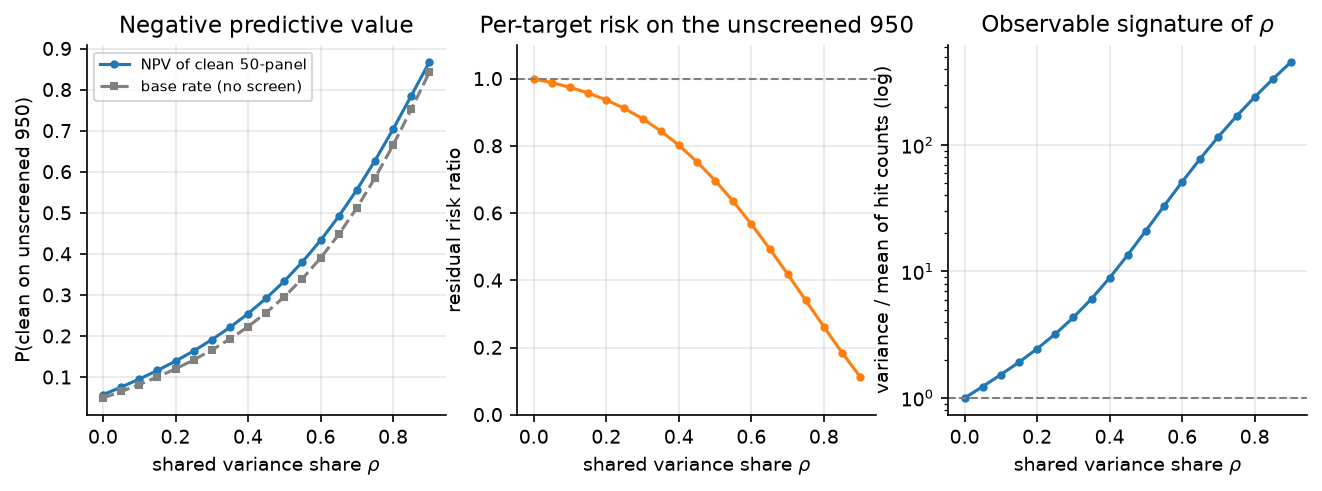

In [8]:
experiment_0()
rho_results = experiment_1()
display(rho_results.round(4))
display(Image(filename=str(FIG / 'fig0_landscape.png')))
display(Image(filename=str(FIG / 'fig1_rho_sweep.png')))

The relationship is smooth. Half the affinity variance must be shared before a clean 50-target panel cuts expected liability elsewhere by even 30%. At $\rho=0.85$, the panel's negative predictive value is high largely because the unconditional fraction of compounds clean everywhere is already high.

## 6. The panel has to be able to fire

A test that almost nothing fails carries almost no information. Holding $\rho=0.6$ while varying the marginal liability rate shows how the informativeness depends on concentration and on the hit threshold, not only on target choice.

,hit_rate,rho,expected_liabilities,p_clean_panel,base_rate_clean,npv,residual_risk_ratio
0,0.0003,0.0,0.3,0.9851,0.7408,0.7520,1.0000
1,0.0003,0.3,0.3,0.9851,0.7510,0.7623,0.9948
2,0.0003,0.6,0.3,0.9855,0.7862,0.7978,0.9528
3,0.0010,0.0,1.0,0.9512,0.3677,0.3866,1.0000
4,0.0010,0.3,1.0,0.9519,0.4395,0.4617,0.9705
5,0.0010,0.6,1.0,0.9574,0.5847,0.6107,0.7957
6,0.0030,0.0,3.0,0.8605,0.0496,0.0576,1.0000
7,0.0030,0.3,3.0,0.8689,0.1664,0.1915,0.8814
8,0.0030,0.6,3.0,0.9012,0.3905,0.4333,0.5675
9,0.0100,0.0,10.0,0.6050,0.0000,0.0001,1.0000


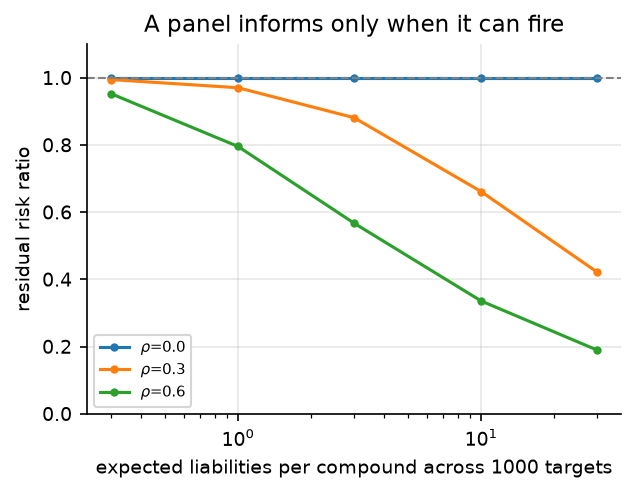

In [9]:
hit_rate_results = experiment_1b()
display(hit_rate_results.round(4))
display(Image(filename=str(FIG / 'fig1b_hit_rate.png')))

## 7. Returns to panel size and composition

Under a single global factor, a panel measures one scalar, $\phi_c$, so any targets are exchangeable. With family structure, composition matters. For a panel of size $n$, the spread design allocates

$$|P\cap F_j|=\lfloor n/F\rfloor+\mathbf{1}\{j\leq n\bmod F\}.$$

The concentrated design fills the families in order. For $n=50$ and $F=20$, the spread design has two or three targets per family, while the concentrated design lies in the first family.

,rho,panel_size,npv,expected_missed,residual_risk_ratio
0,0.00,5,0.0503,2.9850,1.0000
1,0.00,10,0.0511,2.9700,1.0000
2,0.00,20,0.0526,2.9400,1.0000
3,0.00,44,0.0566,2.8680,1.0000
4,0.00,50,0.0576,2.8500,1.0000
5,0.00,100,0.0669,2.7000,1.0000
6,0.00,200,0.0904,2.4000,1.0000
7,0.00,400,0.1649,1.8000,1.0000
8,0.00,800,0.5483,0.6000,1.0000
9,0.30,5,0.1689,2.9372,0.9840


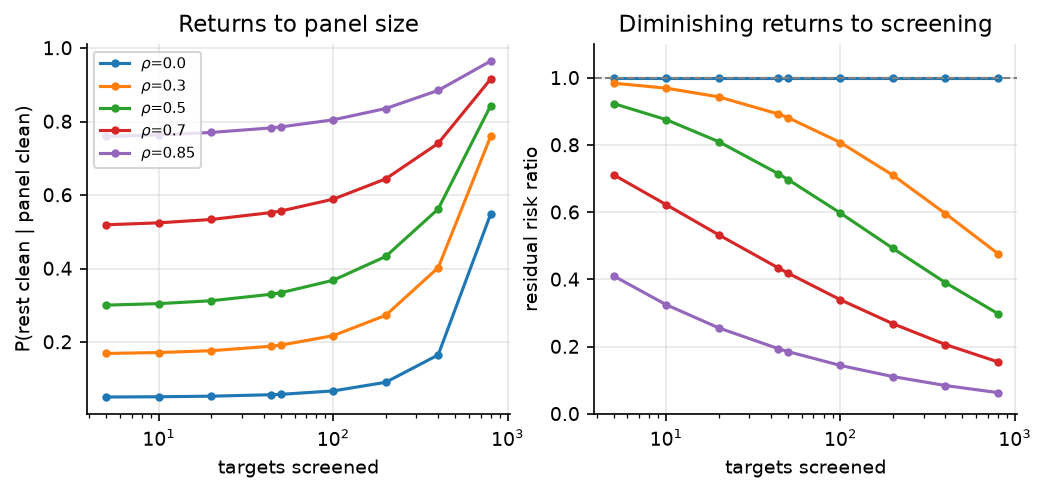

,base_rate,p_clean_panel,npv,expected_missed,residual_risk_ratio,n_clean_panel,structure,rho_global,rho_family,design
0,0.3898,0.9001,0.4330,1.6147,0.5668,180020,global only,0.6,0.0,spread over 20 families
1,0.3898,0.9011,0.4326,1.6218,0.5693,180213,global only,0.6,0.0,concentrated in 1 family
2,0.2774,0.8818,0.3146,2.0746,0.7295,176352,"half global, half family",0.3,0.3,spread over 20 families
3,0.2774,0.9003,0.3081,2.3794,0.8366,180069,"half global, half family",0.3,0.3,concentrated in 1 family
4,0.1231,0.8651,0.1423,2.5643,0.8979,173017,family only,0.0,0.6,spread over 20 families
5,0.1231,0.9020,0.1365,2.8609,1.0017,180395,family only,0.0,0.6,concentrated in 1 family


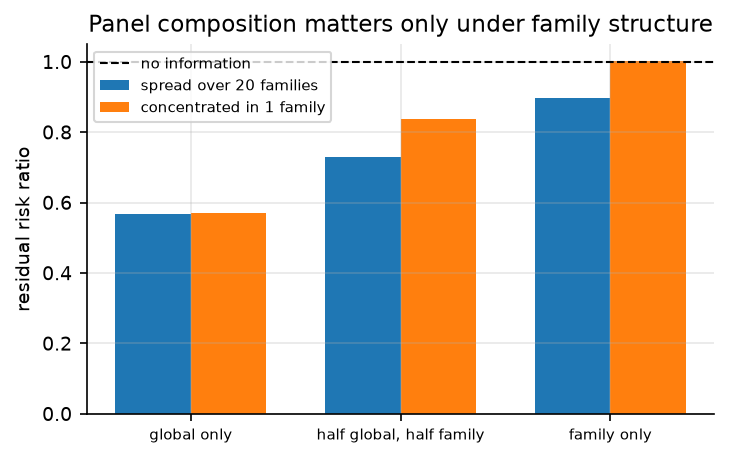

In [10]:
panel_size_results = experiment_2()
display(panel_size_results.round(4))
display(Image(filename=str(FIG / 'fig2_panel_size.png')))

family_results = experiment_4()
display(family_results.round(4))
display(Image(filename=str(FIG / 'fig4_family_structure.png')))

Under global-only structure, spread and concentrated panels are statistically indistinguishable. Under family-only structure, a concentrated panel measures one family's promiscuity and says little about the other 19, while spreading the same number of assays across families provides broader information.

## 8. Heavy tails blunt the panel

At fixed $\rho$, a heavy idiosyncratic tail makes threshold exceedances more likely to arise from one-off compound-target coincidences. Such events are not anticipated by a clean panel elsewhere. Low degrees of freedom correspond to heavier tails.

,nu,rho,npv,base_rate_clean,residual_risk_ratio
0,3.0,0.3,0.1100,0.0949,0.9593
1,3.0,0.5,0.1754,0.1526,0.8739
2,3.0,0.7,0.3188,0.2856,0.6413
3,4.0,0.3,0.1488,0.1288,0.9230
4,4.0,0.5,0.2550,0.2239,0.7823
5,4.0,0.7,0.4494,0.4090,0.5128
6,5.0,0.3,0.1915,0.1664,0.8814
7,5.0,0.5,0.3341,0.2961,0.6974
8,5.0,0.7,0.5565,0.5125,0.4188
9,8.0,0.3,0.2975,0.2610,0.7802


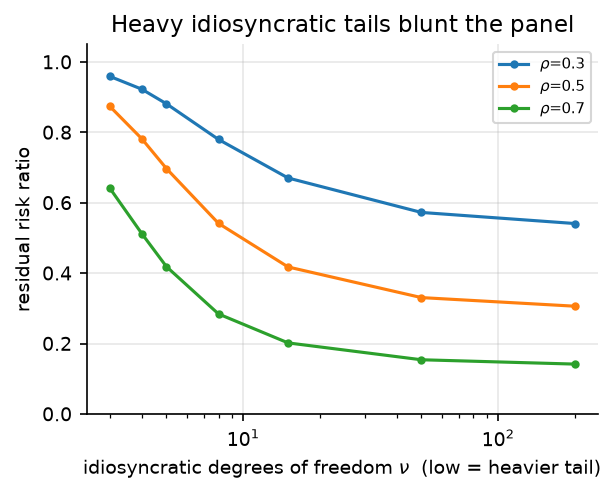

In [11]:
tail_results = experiment_3()
display(tail_results.round(4))
display(Image(filename=str(FIG / 'fig3_tail_weight.png')))

## 9. Estimating the shared structure from panels already run

Shared compound-level structure over-disperses per-compound hit counts relative to the binomial count expected under independence. The variance-to-mean ratio is a diagnostic for whether fitting the factor model is worthwhile. Target-level differences in base rates and assay batch effects can also cause over-dispersion, so they must be accounted for before interpreting it as $\rho$.

The next cells perform the Monte Carlo check and generate the dispersion diagnostic. The family experiment uses 200,000 compounds by default, matching the report.

,rho,npv_analytic,npv_mc,rrr_analytic,rrr_mc,base_rate_analytic,base_rate_mc,vmr_analytic_1000,vmr_mc_44,frac_clean_on_44,n_clean_panel
0,0.0,0.0576,0.0579,1.0000,0.9996,0.0496,0.0498,0.9970,0.9922,0.8750,171843
1,0.3,0.1915,0.1906,0.8814,0.8831,0.1664,0.1658,4.3248,1.1390,0.8832,173908
2,0.6,0.4333,0.4310,0.5675,0.5747,0.3905,0.3882,51.2257,2.9279,0.9102,180117


,n_panel,rho,mean_hits_in_panel,vmr_in_panel,residual_risk_ratio
19,44,0.00,0.132,0.9970,1.0000
20,44,0.05,0.132,1.0070,0.9886
21,44,0.10,0.132,1.0198,0.9747
22,44,0.15,0.132,1.0366,0.9578
23,44,0.20,0.132,1.0594,0.9371
24,44,0.25,0.132,1.0918,0.9119
25,44,0.30,0.132,1.1402,0.8814
26,44,0.35,0.132,1.2157,0.8451
27,44,0.40,0.132,1.3374,0.8024
28,44,0.45,0.132,1.5365,0.7532


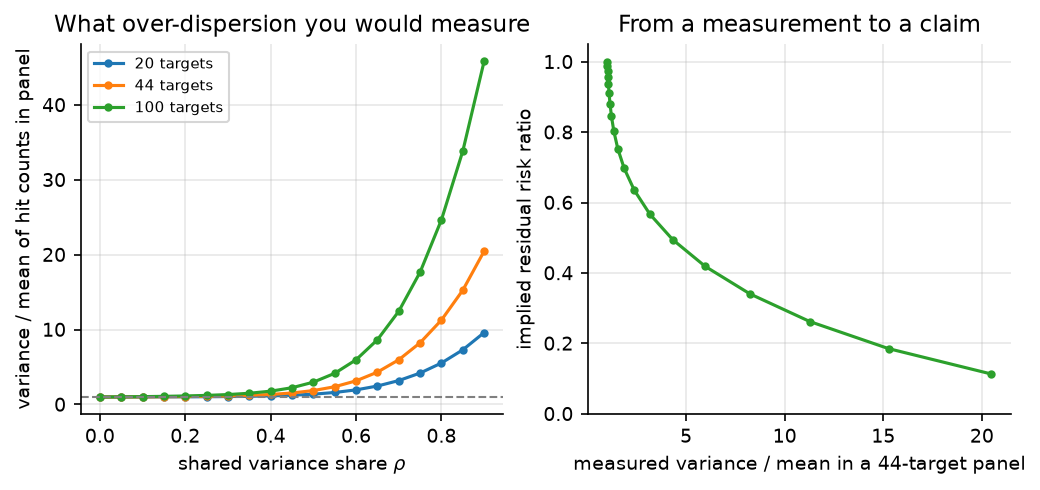

In [12]:
mc_results = experiment_5()
display(mc_results.round(4))

dispersion_results = experiment_6()
display(dispersion_results[dispersion_results.n_panel == 44].round(4))
display(Image(filename=str(FIG / 'fig5_dispersion_diagnostic.png')))

## 10. Suggestions on how to set this up

For one shared factor, covariance between targets and a compound-level shift are algebraically the same model. The decisions that matter are how many shared factors exist, whether the idiosyncratic tail is heavy, whether target-specific marginals need to be modeled, and how much prior information predicts the global factor.

A Gaussian factor copula could preserve the dependence structure while giving different targets different empirical affinity distributions. Physicochemical predictors such as lipophilicity and basicity could make the global promiscuity factor partly predictable. Target-level base-rate variation is a separate mechanism: it can justify screening a target directly but does not, by itself, support inference from screened to unscreened targets.

## 11. Limitations

The threshold is fixed and known, whereas clinical-exposure margins vary by compound and target. All targets are treated as equally consequential, the 1000-target universe and hit rate are illustrative, and the compound population is assumed exchangeable with the population used to estimate the shared structure. False negatives are not modeled. Within a lead series, scaffold-driven profiles could create an additional intermediate factor.

## Reproducibility

The notebook uses the same seeded functions as `run_all.py`. It writes figures to `figures/`, tabular outputs to `results/`, and can be run with the repository environment:

```bash
.venv/bin/python -m pip install -r requirements.txt
.venv/bin/python -m pip install jupyter
```

References: Bowes et al., *Nature Reviews Drug Discovery* 11(12):909–922 (2012), and Leeson & Springthorpe, *Nature Reviews Drug Discovery* 6(11):881–890 (2007). See `report.md` for full citations and links.